# CNN-LSTM para previsão de carga em 24 horas

Este notebook treina uma CNN-LSTM com duas entradas sobre os arquivos `.npz` gerados por `create_window_datasets.py`.

- `X_past`: carga e componentes PCA observadas de `t-23` até `t`;
- `X_calendar`: calendário conhecido de `t+1` até `t+24`;
- `y`: carga a prever de `t+1` até `t+24`.

As configurações e o número de épocas são escolhidos no conjunto de validação. Depois, o modelo é ajustado em `train + validation` e o teste, que corresponde à cauda temporal do dataset, é usado uma única vez para a avaliação final.

In [4]:
from __future__ import annotations

import copy
import json
import random
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset


## Configuração pelo usuário

Edite somente este bloco para escolher o arquivo de entrada, o dispositivo, os parâmetros de treino e as arquiteturas testadas. Cada item de `MODEL_CONFIG_GRID` corresponde a um experimento.

In [5]:
ROOT = next(directory for directory in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (directory / 'ml').is_dir())
INPUT_NPZ = ROOT / 'ml/data/training/BA_SE_ml_input_windows_24h.npz'
INPUT_PARQUET = ROOT / 'ml/data/training/BA_SE_ml_input.parquet'

# Visualização de previsões do teste: uma amostra por data no horário escolhido.
PLOT_TEST_DATES = 14
PLOT_START_HOUR = 0
OUTPUT_DIRECTORY = ROOT / 'ml/models/cnn_lstm/BA_SE'

SEED = 42
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 128
MAX_EPOCHS = 50
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-5
PATIENCE = 8
NUM_WORKERS = 0  # Aumente se o ambiente suportar multiprocessamento.

# Gera seeds aleatórias de modo reproduzível. Altere MASTER_SEED para outra lista.
MASTER_SEED = 20260926
N_SEEDS = 10
seed_generator = np.random.default_rng(MASTER_SEED)
SEEDS = tuple(seed_generator.integers(1, 2**31 - 1, size=N_SEEDS).tolist())
print(f'Seeds do experimento: {SEEDS}')
# Altere, remova ou adicione configurações nesta lista.
MODEL_CONFIG_GRID = [
    # {
    #     'name': 'baseline',
    #     'conv_filters': (64,),
    #     'kernel_size': 3,
    #     'lstm_hidden_size': 64,
    #     'calendar_hidden_size': 32,
    #     'dropout': 0.10,
    # },
    {
        'name': 'larger_cnn_lstm',
        'conv_filters': (64, 128),
        'kernel_size': 3,
        'lstm_hidden_size': 128,
        'calendar_hidden_size': 64,
        'dropout': 0.20,
    },
]

assert INPUT_PARQUET.is_file(), f'Parquet consolidado não encontrado: {INPUT_PARQUET}'
assert INPUT_NPZ.is_file(), (
    f'Arquivo não encontrado: {INPUT_NPZ}. Execute antes: '
    'uv run python ml/scripts/create_window_datasets.py'
)
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
print(f'Dispositivo: {DEVICE}')
print(f'Entrada: {INPUT_NPZ}')


Seeds do experimento: (1805214274, 1798703776, 2066915355, 1773210922, 1874492600, 1309290349, 165829630, 1701472255, 1092525676, 2086521252)
Dispositivo: cuda
Entrada: /home/alves/projetos/egide/ml/data/training/BA_SE_ml_input_windows_24h.npz


## Leitura e validação das janelas

A validação abaixo impede formatos incompatíveis, como calendários com horizonte diferente do alvo. Os dados já foram normalizados no pipeline de origem; portanto, as métricas são reportadas na escala normalizada da carga.

O Parquet consolidado é lido somente para recuperar os timestamps do teste que correspondem às matrizes do `.npz`; ele não é usado para alterar as janelas nem os valores de entrada.


In [ ]:
ARRAY_NAMES = (
    'X_past_train', 'X_calendar_train', 'y_train',
    'X_past_val', 'X_calendar_val', 'y_val',
    'X_past_test', 'X_calendar_test', 'y_test',
)

def load_split_target_times(
    parquet_path: Path,
    *,
    split: str,
    lookback: int,
    horizon: int,
    expected_sample_count: int,
) -> np.ndarray:
    """Reconstrói os timestamps do alvo de cada janela de um split."""
    data = pd.read_parquet(parquet_path, columns=['time', 'split'])
    timestamps = (
        pd.to_datetime(data.loc[data['split'] == split, 'time'])
        .sort_values()
        .to_numpy(dtype='datetime64[ns]')
    )
    window_size = lookback + horizon
    hourly_delta = np.timedelta64(1, 'h')
    target_times = [
        timestamps[start + lookback:start + window_size]
        for start in range(len(timestamps) - window_size + 1)
        if np.all(np.diff(timestamps[start:start + window_size]) == hourly_delta)
    ]
    result = (
        np.stack(target_times)
        if target_times
        else np.empty((0, horizon), dtype='datetime64[ns]')
    )
    assert len(result) == expected_sample_count, (
        f'Os timestamps reconstruídos não correspondem às janelas de {split}. '
        'Confirme que INPUT_NPZ e INPUT_PARQUET pertencem à mesma região e execução.'
    )
    return result


def load_window_data(path: Path) -> dict[str, np.ndarray]:
    """Carrega e valida as nove matrizes do arquivo compactado."""
    with np.load(path) as archive:
        missing = set(ARRAY_NAMES) - set(archive.files)
        if missing:
            raise ValueError(f'Arrays ausentes no NPZ: {sorted(missing)}')
        data = {name: archive[name].astype(np.float32, copy=True) for name in ARRAY_NAMES}

    for split in ('train', 'val', 'test'):
        x_past = data[f'X_past_{split}']
        x_calendar = data[f'X_calendar_{split}']
        target = data[f'y_{split}']
        assert x_past.ndim == 3, f'X_past_{split} deve ter três dimensões.'
        assert x_calendar.ndim == 3, f'X_calendar_{split} deve ter três dimensões.'
        assert target.ndim == 2, f'y_{split} deve ter duas dimensões.'
        assert len(x_past) == len(x_calendar) == len(target)
        assert x_calendar.shape[1] == target.shape[1], (
            'O calendário futuro e o alvo devem ter o mesmo horizonte.'
        )
        assert np.isfinite(x_past).all()
        assert np.isfinite(x_calendar).all()
        assert np.isfinite(target).all()
    return data

windows = load_window_data(INPUT_NPZ)
test_target_times = load_split_target_times(
    INPUT_PARQUET,
    split='test',
    lookback=windows['X_past_test'].shape[1],
    horizon=windows['y_test'].shape[1],
    expected_sample_count=len(windows['y_test']),
)

for split in ('train', 'val', 'test'):
    print(
        split,
        windows[f'X_past_{split}'].shape,
        windows[f'X_calendar_{split}'].shape,
        windows[f'y_{split}'].shape,
    )


train (17861, 24, 134) (17861, 24, 8) (17861, 24)
val (5070, 24, 134) (5070, 24, 8) (5070, 24)
test (2512, 24, 134) (2512, 24, 8) (2512, 24)


## Dataset, arquitetura e métricas

A CNN aplica convoluções ao eixo temporal do passado observado. A LSTM resume esse histórico. Outra LSTM processa o calendário futuro, e a camada final gera um valor para cada uma das 24 horas do horizonte.

In [7]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


class WindowDataset(Dataset):
    """Dataset PyTorch para as duas entradas e o horizonte alvo."""

    def __init__(self, x_past: np.ndarray, x_calendar: np.ndarray, target: np.ndarray):
        self.x_past = torch.from_numpy(x_past)
        self.x_calendar = torch.from_numpy(x_calendar)
        self.target = torch.from_numpy(target)

    def __len__(self) -> int:
        return len(self.target)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        return self.x_past[index], self.x_calendar[index], self.target[index]


@dataclass(frozen=True)
class CNNLSTMConfig:
    conv_filters: tuple[int, ...]
    kernel_size: int
    lstm_hidden_size: int
    calendar_hidden_size: int
    dropout: float


class CNNLSTM(nn.Module):
    """CNN-LSTM com histórico observado e calendário conhecido no futuro."""

    def __init__(
        self,
        past_feature_count: int,
        calendar_feature_count: int,
        config: CNNLSTMConfig,
    ) -> None:
        super().__init__()
        if config.kernel_size <= 0 or config.kernel_size % 2 == 0:
            raise ValueError('kernel_size deve ser ímpar e positivo.')

        convolution_layers: list[nn.Module] = []
        input_channels = past_feature_count
        for output_channels in config.conv_filters:
            convolution_layers.extend([
                nn.Conv1d(
                    input_channels, output_channels, config.kernel_size,
                    padding=config.kernel_size // 2,
                ),
                nn.ReLU(),
                nn.Dropout(config.dropout),
            ])
            input_channels = output_channels
        self.convolution = nn.Sequential(*convolution_layers)
        self.past_lstm = nn.LSTM(
            input_size=input_channels,
            hidden_size=config.lstm_hidden_size,
            batch_first=True,
        )
        self.calendar_lstm = nn.LSTM(
            input_size=calendar_feature_count,
            hidden_size=config.calendar_hidden_size,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(config.lstm_hidden_size + config.calendar_hidden_size, config.lstm_hidden_size),
            nn.ReLU(),
            nn.Dropout(config.dropout),
            nn.Linear(config.lstm_hidden_size, 1),
        )

    def forward(self, x_past: torch.Tensor, x_calendar: torch.Tensor) -> torch.Tensor:
        # Conv1d recebe (amostras, canais/features, tempo).
        convolution_output = self.convolution(x_past.transpose(1, 2)).transpose(1, 2)
        _, (past_hidden, _) = self.past_lstm(convolution_output)
        calendar_output, _ = self.calendar_lstm(x_calendar)

        past_context = past_hidden[-1].unsqueeze(1).expand(-1, x_calendar.size(1), -1)
        combined = torch.cat((past_context, calendar_output), dim=-1)
        return self.head(combined).squeeze(-1)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    """Calcula erros agregados sobre todas as amostras e horizontes."""
    error = y_pred - y_true
    absolute_error = np.abs(error)
    denominator = np.maximum(np.abs(y_true), 1e-6)
    rmse = float(np.sqrt(np.mean(np.square(error))))
    target_range = float(np.ptp(y_true))
    residual_sum_of_squares = float(np.sum(np.square(error)))
    total_sum_of_squares = float(np.sum(np.square(y_true - y_true.mean())))
    return {
        'mae': float(absolute_error.mean()),
        'rmse': rmse,
        'nrmse_percent': float(100 * rmse / max(target_range, 1e-6)),
        'r2': float(1 - residual_sum_of_squares / max(total_sum_of_squares, 1e-6)),
        'mape_percent': float(100 * np.mean(absolute_error / denominator)),
        'smape_percent': float(
            100 * np.mean(2 * absolute_error / np.maximum(np.abs(y_true) + np.abs(y_pred), 1e-6))
        ),
    }


## Early stopping e seleção na validação

Cada arquitetura e seed é treinada somente em `train`. O conjunto `validation` orienta o early stopping e a seleção da configuração.

A seleção usa a média do RMSE de validação entre as seeds. O teste permanece totalmente isolado até a avaliação final.


In [8]:
def make_loader(
    x_past: np.ndarray,
    x_calendar: np.ndarray,
    target: np.ndarray,
    *,
    shuffle: bool,
) -> DataLoader:
    """Cria um DataLoader para um subconjunto temporal já definido."""
    dataset = WindowDataset(x_past, x_calendar, target)
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.startswith('cuda'),
    )


def concatenate_splits(
    data: dict[str, np.ndarray], splits: tuple[str, ...]
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Concatena splits completos para o ajuste final, sem criar novas janelas."""
    return tuple(
        np.concatenate([data[f'{prefix}_{split}'] for split in splits], axis=0)
        for prefix in ('X_past', 'X_calendar', 'y')
    )


def predict(model: nn.Module, loader: DataLoader, device: str) -> tuple[np.ndarray, np.ndarray]:
    """Calcula previsões sem gradientes e devolve alvo e previsão alinhados."""
    model.eval()
    predictions, targets = [], []
    with torch.no_grad():
        for x_past, x_calendar, target in loader:
            output = model(x_past.to(device), x_calendar.to(device))
            predictions.append(output.cpu().numpy())
            targets.append(target.numpy())
    return np.concatenate(targets), np.concatenate(predictions)


def train_configuration(
    config: CNNLSTMConfig,
    train_arrays: tuple[np.ndarray, np.ndarray, np.ndarray],
    validation_arrays: tuple[np.ndarray, np.ndarray, np.ndarray],
    *,
    seed: int,
) -> tuple[pd.DataFrame, dict[str, float]]:
    """Treina em train e restaura o estado de menor RMSE em validation."""
    set_seed(seed)
    train_loader = make_loader(*train_arrays, shuffle=True)
    validation_loader = make_loader(*validation_arrays, shuffle=False)
    model = CNNLSTM(
        past_feature_count=train_arrays[0].shape[-1],
        calendar_feature_count=train_arrays[1].shape[-1],
        config=config,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.MSELoss()

    best_state, best_epoch, best_validation_rmse = None, 0, float('inf')
    epochs_without_improvement = 0
    history = []
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        losses = []
        for x_past, x_calendar, target in train_loader:
            optimizer.zero_grad()
            output = model(x_past.to(DEVICE), x_calendar.to(DEVICE))
            loss = criterion(output, target.to(DEVICE))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            losses.append(loss.item())

        validation_true, validation_pred = predict(model, validation_loader, DEVICE)
        validation_metrics = regression_metrics(validation_true, validation_pred)
        history.append({'epoch': epoch, 'train_mse': float(np.mean(losses)), **validation_metrics})
        if validation_metrics['rmse'] < best_validation_rmse:
            best_state = copy.deepcopy(model.state_dict())
            best_epoch, best_validation_rmse = epoch, validation_metrics['rmse']
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                break

    assert best_state is not None
    model.load_state_dict(best_state)
    validation_true, validation_pred = predict(model, validation_loader, DEVICE)
    final_metrics = regression_metrics(validation_true, validation_pred)
    history_frame = pd.DataFrame(history)
    final_metrics['best_epoch'] = best_epoch
    return history_frame, final_metrics


def train_for_fixed_epochs(
    config: CNNLSTMConfig,
    train_arrays: tuple[np.ndarray, np.ndarray, np.ndarray],
    *,
    seed: int,
    epochs: int,
) -> CNNLSTM:
    """Ajusta um modelo pelo número de épocas selecionado na validação."""
    set_seed(seed)
    model = CNNLSTM(
        past_feature_count=train_arrays[0].shape[-1],
        calendar_feature_count=train_arrays[1].shape[-1],
        config=config,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    criterion = nn.MSELoss()
    train_loader = make_loader(*train_arrays, shuffle=True)
    for _ in range(epochs):
        model.train()
        for x_past, x_calendar, target in train_loader:
            optimizer.zero_grad()
            loss = criterion(
                model(x_past.to(DEVICE), x_calendar.to(DEVICE)),
                target.to(DEVICE),
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
    return model


train_arrays = tuple(
    windows[f'{prefix}_train'] for prefix in ('X_past', 'X_calendar', 'y')
)
validation_arrays = tuple(
    windows[f'{prefix}_val'] for prefix in ('X_past', 'X_calendar', 'y')
)

selection_runs = []
histories = {}
config_by_name = {}
best_validation_rmse_seen = float('inf')
for experiment in MODEL_CONFIG_GRID:
    experiment = experiment.copy()
    name = experiment.pop('name')
    if name in config_by_name:
        raise ValueError(f'Nome de configuração duplicado: {name}')
    config = CNNLSTMConfig(**experiment)
    config_by_name[name] = config
    configuration_runs = []

    for seed in SEEDS:
        history, validation_metrics = train_configuration(
            config,
            train_arrays,
            validation_arrays,
            seed=seed,
        )
        histories.setdefault(name, history)
        run_result = {
            'name': name,
            'seed': seed,
            **asdict(config),
            **validation_metrics,
        }
        selection_runs.append(run_result)
        configuration_runs.append(run_result)

    configuration_mean_rmse = float(
        np.mean([run['rmse'] for run in configuration_runs])
    )
    if configuration_mean_rmse < best_validation_rmse_seen:
        best_validation_rmse_seen = configuration_mean_rmse
        print(
            f'Novo melhor: {name} | RMSE validação={configuration_mean_rmse:.5f} | '
            f'nRMSE validação={np.mean([run["nrmse_percent"] for run in configuration_runs]):.2f}% | '
            f'R² validação={np.mean([run["r2"] for run in configuration_runs]):.4f}'
        )

selection_runs_frame = pd.DataFrame(selection_runs)
METRIC_NAMES = ('mae', 'rmse', 'nrmse_percent', 'r2', 'mape_percent', 'smape_percent', 'best_epoch')
selection_metrics = selection_runs_frame.groupby('name')[list(METRIC_NAMES)].agg(['mean', 'std'])
selection_metrics.columns = [f'{metric}_{stat}' for metric, stat in selection_metrics.columns]
selection_summary = (
    selection_runs_frame.drop_duplicates('name')[['name', 'conv_filters', 'kernel_size', 'lstm_hidden_size', 'calendar_hidden_size', 'dropout']]
    .merge(selection_metrics.reset_index(), on='name')
    .sort_values('rmse_mean', ignore_index=True)
)
selection_runs_frame.to_csv(OUTPUT_DIRECTORY / 'validation_selection_runs.csv', index=False)
selection_summary.to_csv(OUTPUT_DIRECTORY / 'validation_selection_summary.csv', index=False)
selection_summary


Novo melhor: larger_cnn_lstm | RMSE validação=0.06323 | nRMSE validação=5.08% | R² validação=0.9720


,name,conv_filters,kernel_size,lstm_hidden_size,calendar_hidden_size,dropout,mae_mean,mae_std,rmse_mean,rmse_std,nrmse_percent_mean,nrmse_percent_std,r2_mean,r2_std,mape_percent_mean,mape_percent_std,smape_percent_mean,smape_percent_std,best_epoch_mean,best_epoch_std
0,larger_cnn_lstm,"(64, 128)",3,128,64,0.2,0.034779,0.001043,0.06323,0.001501,5.077334,0.120526,0.97203,0.001338,109302.698828,29979.625304,99.924343,0.742099,11.3,4.056545


## Ajuste final e avaliação única no teste

A melhor arquitetura é escolhida pela média do RMSE de validação entre as seeds. Cada seed é então ajustada em `train + validation` pelo número mediano de épocas selecionado. O teste não participa de nenhuma decisão e recebe uma única avaliação final, sobre a média das previsões das seeds.


In [9]:
best_name = selection_summary.loc[0, 'name']
best_config = config_by_name[best_name]
selected_runs = selection_runs_frame.loc[selection_runs_frame['name'] == best_name]
final_epochs = max(1, int(round(selected_runs['best_epoch'].median())))

final_train_arrays = concatenate_splits(windows, ('train', 'val'))
test_arrays = tuple(
    windows[f'{prefix}_test'] for prefix in ('X_past', 'X_calendar', 'y')
)
test_loader = make_loader(*test_arrays, shuffle=False)
test_predictions = []

for seed in SEEDS:
    model = train_for_fixed_epochs(
        best_config,
        final_train_arrays,
        seed=seed,
        epochs=final_epochs,
    )
    test_true, seed_prediction = predict(model, test_loader, DEVICE)
    test_predictions.append(seed_prediction)
    torch.save(
        {
            'model_state_dict': model.state_dict(),
            'model_config': asdict(best_config),
            'seed': seed,
            'epochs': final_epochs,
        },
        OUTPUT_DIRECTORY / f'{best_name}_final_seed{seed}.pt',
    )

# Única avaliação do teste: ensemble da configuração já selecionada.
test_pred = np.mean(test_predictions, axis=0)
test_metrics = regression_metrics(test_true, test_pred)
validation_selection_metrics = {
    metric: float(selection_summary.loc[0, f'{metric}_mean'])
    for metric in METRIC_NAMES
    if metric != 'best_epoch'
}
summary = {
    'best_configuration': best_name,
    'best_model_config': asdict(best_config),
    'validation_selection_mean': validation_selection_metrics,
    'final_epochs': final_epochs,
    'seeds': list(SEEDS),
    'test_ensemble': test_metrics,
}
with (OUTPUT_DIRECTORY / 'best_model_metrics.json').open('w', encoding='utf-8') as file:
    json.dump(summary, file, indent=2)
pd.DataFrame([
    {'split': 'validation_selection_mean', **validation_selection_metrics},
    {'split': 'test_final_ensemble', **test_metrics},
])


,split,mae,rmse,nrmse_percent,r2,mape_percent,smape_percent
0,validation_selection_mean,0.034779,0.063230,5.077334,0.972030,109302.698828,99.924343
1,test_final_ensemble,0.024459,0.046073,3.671034,0.983318,76200.023438,104.852257


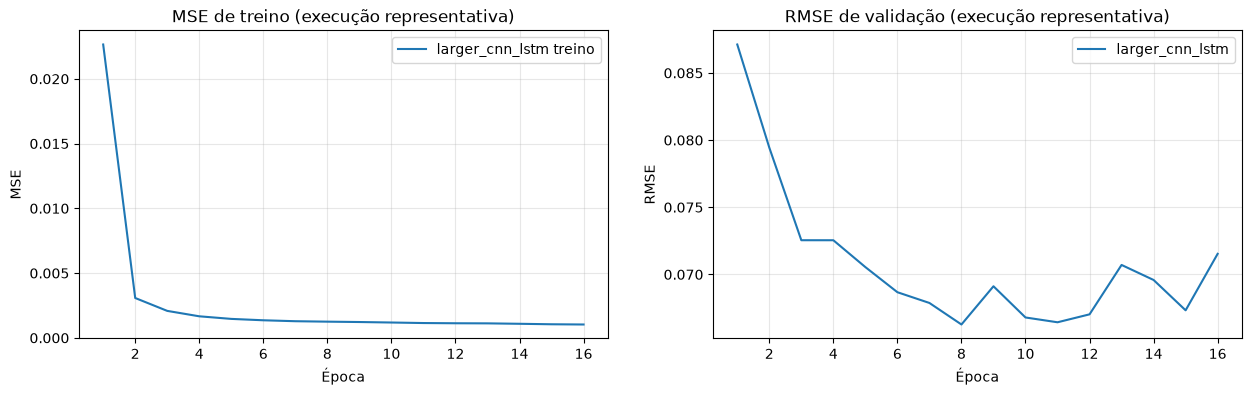

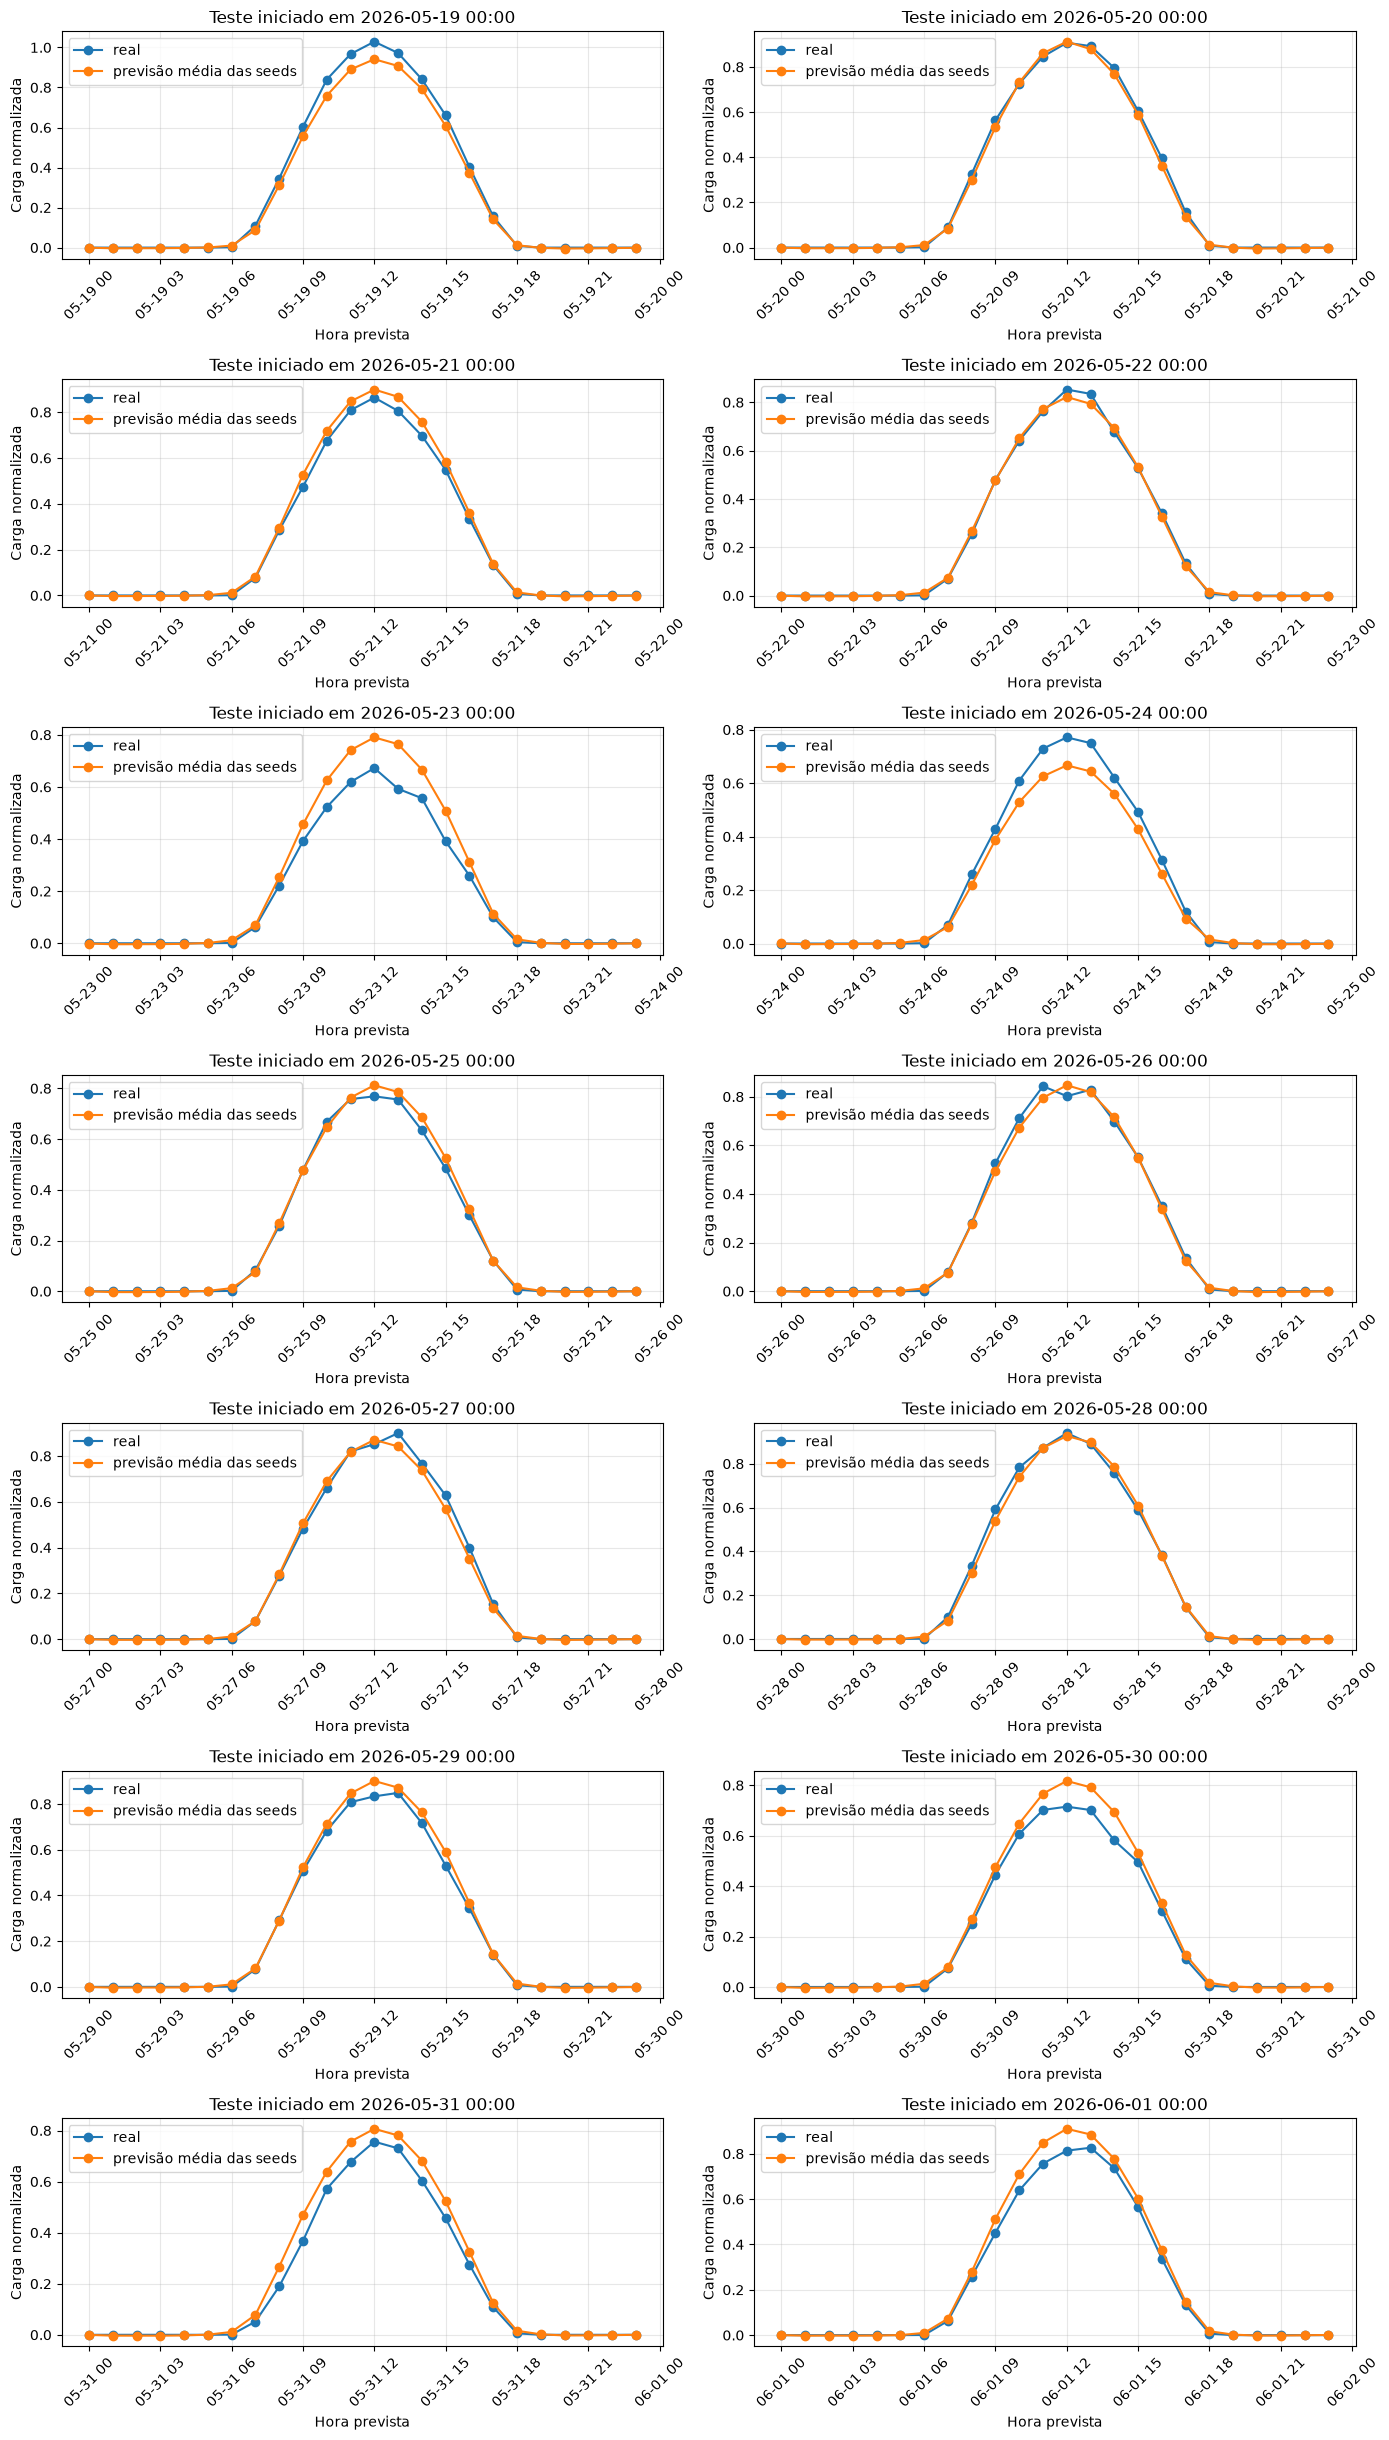

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

for name, history in histories.items():
    axes[0].plot(history['epoch'], history['train_mse'], label=f'{name} treino')
    axes[1].plot(history['epoch'], history['rmse'], label=name)
axes[0].set(title='MSE de treino (execução representativa)', xlabel='Época', ylabel='MSE')
axes[1].set(title='RMSE de validação (execução representativa)', xlabel='Época', ylabel='RMSE')
for axis in axes:
    axis.legend()
    axis.grid(alpha=0.3)
plt.show()

test_start_times = pd.DatetimeIndex(test_target_times[:, 0])
selected_indices = np.flatnonzero(test_start_times.hour == PLOT_START_HOUR)
selected_indices = selected_indices[:PLOT_TEST_DATES]
if len(selected_indices) < PLOT_TEST_DATES:
    raise ValueError(
        f'Foram encontradas somente {len(selected_indices)} datas iniciando às '
        f'{PLOT_START_HOUR:02d}:00 no teste.'
    )

n_columns = min(2, PLOT_TEST_DATES)
n_rows = int(np.ceil(PLOT_TEST_DATES / n_columns))
figure, axes = plt.subplots(n_rows, n_columns, figsize=(14, 3.5 * n_rows), squeeze=False)
for axis, sample_index in zip(axes.flat, selected_indices):
    target_times = pd.DatetimeIndex(test_target_times[sample_index])
    axis.plot(target_times, test_true[sample_index], marker='o', label='real')
    axis.plot(target_times, test_pred[sample_index], marker='o', label='previsão média das seeds')
    axis.set_title(f'Teste iniciado em {target_times[0]:%Y-%m-%d %H:%M}')
    axis.set_xlabel('Hora prevista')
    axis.set_ylabel('Carga normalizada')
    axis.tick_params(axis='x', rotation=45)
    axis.grid(alpha=0.3)
    axis.legend()
for axis in axes.flat[len(selected_indices):]:
    axis.set_visible(False)
figure.tight_layout()
plt.show()
